# 🏥 Predicción de Lesión de Ligamento Cruzado Anterior (ACL) desde DICOM

---

## 📋 Descripción General

**Autor**: Pablo Lodo  
**Fecha**: Marzo 2026  
**Versión**: 1.0

### 🎯 Objetivo

Este notebook permite realizar predicciones de lesiones del ligamento cruzado anterior (ACL) a partir de archivos DICOM comprimidos en formato ZIP.

### 📦 Funcionalidades

1. **Extracción de ZIP**: Descomprime archivos DICOM desde un archivo ZIP
2. **Preprocesamiento**: Convierte imágenes DICOM a formato NPY organizadas por plano anatómico
3. **Carga de Modelos**: Carga los mejores modelos Vision Transformer entrenados
4. **Predicción**: (A expandir) Realiza predicciones sobre nuevas resonancias

### 🔧 Requisitos

- Python 3.8+
- PyTorch >= 2.0
- pydicom
- numpy
- transformers (HuggingFace)

---

## 1. Importar Librerías Necesarias

In [ ]:
# ==========================================
# IMPORTS
# ==========================================

import os
import sys
import zipfile
import tempfile
import shutil
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple

# Procesamiento de imágenes
import numpy as np
import cv2
from PIL import Image

# DICOM
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut, apply_modality_lut

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import ViTModel, ViTConfig
import torchvision.transforms as transforms

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print(f"📌 PyTorch version: {torch.__version__}")
print(f"📌 CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📌 GPU: {torch.cuda.get_device_name(0)}")

✅ Librerías importadas correctamente
📌 PyTorch version: 2.4.1+cu121
📌 CUDA disponible: True
📌 GPU: NVIDIA H100 PCIe


## 2. Configuración General

Configuración de rutas y parámetros del sistema.

In [30]:
# ==========================================
# CONFIGURACIÓN
# ==========================================

# Rutas
BASE_DIR = Path('..')
CHECKPOINT_DIR = BASE_DIR / 'checkpoints' / 'vit_optimized_pipeline'
OUTPUT_DIR = BASE_DIR / 'data' / 'predicciones'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modelos ACL - Los mejores según métricas AUC
MODEL_PATHS = {
    'sagittal': CHECKPOINT_DIR / 'best_sagittal_auc.pth',
    'coronal': CHECKPOINT_DIR / 'best_coronal_auc.pth',
    'axial': CHECKPOINT_DIR / 'best_axial_auc.pth'
}

# Configuración de selección de slices (según entrenamiento)
PLANE_CONFIG = {
    'sagittal': {
        'num_slices': 5,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '5 slices centrales consecutivos'
    },
    'coronal': {
        'num_slices': 10,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '10 slices centrales consecutivos'
    },
    'axial': {
        'num_slices': 10,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '10 slices centrales consecutivos'
    }
}

# Configuración del modelo ViT
VIT_MODEL_NAME = "google/vit-base-patch16-224"
IMAGE_SIZE = 224
NUM_CLASSES = 1  # Clasificación binaria

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Configuración cargada")
print(f"📁 Checkpoints: {CHECKPOINT_DIR}")
print(f"📁 Output: {OUTPUT_DIR}")
print(f"🖥️  Device: {DEVICE}")
print(f"\n📊 Modelos a cargar:")
for plane, path in MODEL_PATHS.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {plane}: {path.name}")

✅ Configuración cargada
📁 Checkpoints: ../checkpoints/vit_optimized_pipeline
📁 Output: ../data/predicciones
🖥️  Device: cuda

📊 Modelos a cargar:
  ✓ sagittal: best_sagittal_auc.pth
  ✓ coronal: best_coronal_auc.pth
  ✓ axial: best_axial_auc.pth


## 3. Funciones de Preprocesamiento DICOM

Funciones para extraer ZIP, leer archivos DICOM, determinar planos anatómicos y convertir a formato NPY.

In [ ]:
# ==========================================
# FUNCIONES DE PREPROCESAMIENTO DICOM
# ==========================================

def extract_zip(zip_path: Path, extract_to: Path = None) -> Path:
    """
    Extrae un archivo ZIP a un directorio.
    
    Args:
        zip_path: Ruta al archivo ZIP
        extract_to: Directorio de destino (si None, usa temporal)
        
    Returns:
        Path al directorio extraído
    """
    if extract_to is None:
        extract_to = Path(tempfile.mkdtemp())
    
    print(f"📦 Extrayendo ZIP: {zip_path.name}")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    
    print(f"✅ Extraído a: {extract_to}")
    return extract_to


def get_plane_from_dicom(ds) -> str:
    """
    Determina el plano anatómico a partir de los metadatos DICOM.
    
    Args:
        ds: Dataset DICOM (pydicom)
        
    Returns:
        'sagittal', 'coronal', o 'axial'
    """
    try:
        # ImageOrientationPatient: 6 valores [Xx, Xy, Xz, Yx, Yy, Yz]
        orientation = ds.ImageOrientationPatient
        
        row_orient = np.array(orientation[:3])
        col_orient = np.array(orientation[3:])
        
        # Producto cruz para obtener el vector normal al plano
        normal = np.cross(row_orient, col_orient)
        normal = np.abs(normal)
        
        # Determinar eje dominante
        max_idx = np.argmax(normal)
        
        if max_idx == 0:  # X dominante
            return 'sagittal'
        elif max_idx == 1:  # Y dominante
            return 'coronal'
        else:  # Z dominante
            return 'axial'
            
    except (AttributeError, ValueError):
        # Intentar con SeriesDescription
        try:
            desc = ds.SeriesDescription.lower()
            if 'sag' in desc:
                return 'sagittal'
            elif 'cor' in desc:
                return 'coronal'
            elif 'ax' in desc or 'tra' in desc:
                return 'axial'
        except:
            pass
    
    # Por defecto, asumir sagital (plano principal para ACL)
    return 'sagittal'


def read_dicom_slice(dicom_path: Path) -> Tuple[np.ndarray, dict, str]:
    """
    Lee un archivo DICOM y extrae la imagen y metadatos.
    
    Args:
        dicom_path: Ruta al archivo DICOM
        
    Returns:
        (image_array, metadata, plane)
    """
    ds = pydicom.dcmread(str(dicom_path))
    
    # Obtener pixel array
    image = ds.pixel_array.astype(np.float32)
    
    # Aplicar transformaciones de ventana si están disponibles
    try:
        if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
            center = ds.WindowCenter
            width = ds.WindowWidth
            
            if isinstance(center, (list, tuple)):
                center = center[0]
            if isinstance(width, (list, tuple)):
                width = width[0]
            
            lower = center - width / 2
            upper = center + width / 2
            image = np.clip(image, lower, upper)
    except:
        pass
    
    # Normalizar a [0, 255]
    image = ((image - image.min()) / (image.max() - image.min() + 1e-8) * 255).astype(np.uint8)
    
    # Extraer metadatos relevantes
    metadata = {
        'PatientID': getattr(ds, 'PatientID', 'Unknown'),
        'StudyDate': getattr(ds, 'StudyDate', 'Unknown'),
        'SeriesDescription': getattr(ds, 'SeriesDescription', 'Unknown'),
        'SliceLocation': getattr(ds, 'SliceLocation', None),
        'InstanceNumber': getattr(ds, 'InstanceNumber', None)
    }
    
    # Determinar plano
    plane = get_plane_from_dicom(ds)
    
    return image, metadata, plane


def find_dicom_files(directory: Path) -> List[Path]:
    """
    Busca recursivamente todos los archivos DICOM en un directorio.
    
    Args:
        directory: Directorio a buscar
        
    Returns:
        Lista de rutas a archivos DICOM
    """
    dicom_files = []
    
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = Path(root) / file
            
            try:
                pydicom.dcmread(file_path, stop_before_pixels=True)
                dicom_files.append(file_path)
            except:
                continue
    
    print(f"✅ Encontrados {len(dicom_files)} archivos DICOM")
    return dicom_files


def process_dicom_to_npy(dicom_dir: Path, output_dir: Path) -> Dict[str, Path]:
    """
    Procesa archivos DICOM y los organiza por plano anatómico en archivos NPY.
    
    Args:
        dicom_dir: Directorio con archivos DICOM
        output_dir: Directorio de salida para archivos NPY
        
    Returns:
        Diccionario {plane: npy_path}
    """
    print("\n🔄 Procesando archivos DICOM...")
    
    # Encontrar archivos DICOM
    dicom_files = find_dicom_files(dicom_dir)
    
    if not dicom_files:
        raise ValueError(f"No se encontraron archivos DICOM en {dicom_dir}")
    
    # Organizar por plano
    planes_data = defaultdict(list)
    
    for dicom_file in dicom_files:
        try:
            image, metadata, plane = read_dicom_slice(dicom_file)
            slice_location = metadata.get('SliceLocation', 0)
            instance_number = metadata.get('InstanceNumber', 0)
            
            planes_data[plane].append({
                'image': image,
                'slice_location': slice_location,
                'instance_number': instance_number,
                'metadata': metadata
            })
        except Exception as e:
            print(f"⚠️  Error procesando {dicom_file.name}: {e}")
            continue
    
    # Guardar archivos NPY organizados por plano
    output_paths = {}
    
    for plane, slices in planes_data.items():
        # Ordenar por ubicación de slice o número de instancia
        slices.sort(key=lambda x: (x['slice_location'] or 0, x['instance_number'] or 0))
        
        # Apilar imágenes en volumen 3D
        volume = np.stack([s['image'] for s in slices], axis=0)
        
        # Guardar como NPY
        output_path = output_dir / f"{plane}.npy"
        np.save(output_path, volume)
        output_paths[plane] = output_path
        
        print(f"  ✅ {plane:10s}: {volume.shape[0]:3d} slices → {output_path.name}")
    
    print(f"\n✅ Procesamiento completado: {len(output_paths)} planos")
    return output_paths

print("✅ Funciones de preprocesamiento definidas")

✅ Funciones de preprocesamiento definidas


## 4. Definición del Modelo ACL

Arquitectura del modelo Vision Transformer (ViT) para clasificación ACL con multi-slice pooling.

In [32]:
# ==========================================
# ARQUITECTURA DEL MODELO
# ==========================================

class AttentionPooling(nn.Module):
    """Attention pooling para agregar múltiples slices."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 128),  # Fijo: 768 -> 128 (coincide con checkpoint)
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # x: [batch, num_slices, hidden_size]
        attn_weights = torch.softmax(self.attention(x), dim=1)  # [batch, num_slices, 1]
        pooled = torch.sum(x * attn_weights, dim=1)  # [batch, hidden_size]
        return pooled, attn_weights.squeeze(-1)  # Retornar también los pesos


class ACLClassifier(nn.Module):
    """
    Clasificador ACL usando Vision Transformer (ViT).
    
    Procesa múltiples slices y usa attention pooling para agregar información.
    """
    def __init__(
        self,
        model_name: str = "google/vit-base-patch16-224",
        num_classes: int = 1,
        pooling_mode: str = 'attention',
        dropout: float = 0.3
    ):
        super().__init__()
        
        self.pooling_mode = pooling_mode
        
        # Cargar ViT pre-entrenado
        self.vit = ViTModel.from_pretrained(model_name)
        hidden_size = self.vit.config.hidden_size  # 768 para ViT-base
        
        # Pooling layer
        if pooling_mode == 'attention':
            self.pooling = AttentionPooling(hidden_size)
        else:
            self.pooling = None  # MaxPool se hace en forward
        
        # Clasificador - ARQUITECTURA ORIGINAL (768 -> 256 -> 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),  # Fijo: 768 -> 256 (coincide con checkpoint)
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)  # Fijo: 256 -> 1
        )
    
    def forward(self, x):
        """
        Args:
            x: Tensor [batch, num_slices, channels, height, width]
            
        Returns:
            logits: [batch, num_classes]
            attention_weights: [batch, num_slices] o None
        """
        batch_size, num_slices, c, h, w = x.shape
        
        # Reshape para procesar todos los slices juntos
        x = x.view(batch_size * num_slices, c, h, w)
        
        # Pasar por ViT
        outputs = self.vit(pixel_values=x)
        slice_features = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Reshape back
        slice_features = slice_features.view(batch_size, num_slices, -1)
        
        # Pooling
        attention_weights = None
        if self.pooling_mode == 'attention':
            pooled_features, attention_weights = self.pooling(slice_features)
        else:  # max pooling
            pooled_features = torch.max(slice_features, dim=1)[0]
        
        # Clasificación
        logits = self.classifier(pooled_features)
        
        return logits, attention_weights

print("✅ Arquitectura del modelo definida (compatible con checkpoints)")

✅ Arquitectura del modelo definida (compatible con checkpoints)


## 5. Cargar Modelos Pre-entrenados

Cargamos los mejores modelos entrenados para cada plano anatómico.

In [33]:
# ==========================================
# CARGA DE MODELOS
# ==========================================

def load_acl_model(checkpoint_path: Path, plane: str, device: torch.device) -> ACLClassifier:
    """
    Carga un modelo ACL pre-entrenado desde checkpoint.
    
    Args:
        checkpoint_path: Ruta al archivo .pth
        plane: Plano anatómico ('sagittal', 'coronal', 'axial')
        device: Dispositivo (cuda/cpu)
        
    Returns:
        Modelo cargado en modo evaluación
    """
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint no encontrado: {checkpoint_path}")
    
    # Cargar checkpoint primero para inspeccionar
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    # Manejar diferentes formatos de checkpoint
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    
    # Remover prefijo 'module.' si existe (de DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[name] = v
    
    # DETECTAR automáticamente el pooling mode del checkpoint
    has_attention_pooling = 'pooling.attention.0.weight' in new_state_dict
    detected_pooling = 'attention' if has_attention_pooling else 'max'
    
    print(f"  🔍 Pooling mode detectado: {detected_pooling}")
    
    # Crear modelo con el pooling correcto
    model = ACLClassifier(
        model_name=VIT_MODEL_NAME,
        num_classes=NUM_CLASSES,
        pooling_mode=detected_pooling
    )
    
    # Cargar pesos
    model.load_state_dict(new_state_dict)
    model = model.to(device)
    model.eval()
    
    # Mostrar información del checkpoint
    if 'val_auc' in checkpoint:
        print(f"  📊 Validation AUC: {checkpoint['val_auc']:.4f}")
    if 'val_f1' in checkpoint:
        print(f"  📊 Validation F1: {checkpoint['val_f1']:.4f}")
    
    return model


# Cargar modelos para todos los planos
models = {}

print("\n🔄 Cargando modelos pre-entrenados...\n")

for plane, checkpoint_path in MODEL_PATHS.items():
    try:
        print(f"📥 Cargando modelo para plano {plane.upper()}...")
        model = load_acl_model(checkpoint_path, plane, DEVICE)
        models[plane] = model
        print(f"✅ Modelo {plane} cargado exitosamente\n")
    except Exception as e:
        print(f"❌ Error cargando modelo {plane}: {e}\n")
        models[plane] = None

# Verificar qué modelos se cargaron
loaded_planes = [p for p, m in models.items() if m is not None]
print(f"\n✅ Modelos cargados: {', '.join(loaded_planes)}")
print(f"📊 Total: {len(loaded_planes)}/3 modelos disponibles")


🔄 Cargando modelos pre-entrenados...

📥 Cargando modelo para plano SAGITTAL...
  🔍 Pooling mode detectado: attention


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  📊 Validation AUC: 0.9534
  📊 Validation F1: 0.8000
✅ Modelo sagittal cargado exitosamente

📥 Cargando modelo para plano CORONAL...
  🔍 Pooling mode detectado: max


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  📊 Validation AUC: 0.9346
  📊 Validation F1: 0.7467
✅ Modelo coronal cargado exitosamente

📥 Cargando modelo para plano AXIAL...
  🔍 Pooling mode detectado: attention


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  📊 Validation AUC: 0.9755
  📊 Validation F1: 0.8421
✅ Modelo axial cargado exitosamente


✅ Modelos cargados: sagittal, coronal, axial
📊 Total: 3/3 modelos disponibles


## 5b. CNN Selector para Slices Sagitales

El plano sagital usa un CNN pre-entrenado para seleccionar los 5 slices más informativos (aquellos con mayor probabilidad de mostrar el ACL visible).

In [34]:
# ==========================================
# CNN SELECTOR PARA SLICES SAGITALES
# ==========================================

import timm

# Arquitectura del CNN Selector
class ACLSliceClassifier(nn.Module):
    """
    CNN que clasifica si un slice individual contiene ACL visible.
    Arquitectura: MobileNetV2 (pretrained) + classifier custom
    """
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('mobilenetv2_100', pretrained=pretrained, num_classes=0)
        
        # Classifier custom
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)  # 2 clases: [sin ACL, con ACL]
        )
    
    def forward(self, x):
        return self.backbone(x)


class SimpleCNNSelector(nn.Module):
    """
    Wrapper del CNN Selector para seleccionar slices informativos.
    """
    def __init__(self, checkpoint_path, device='cuda:0'):
        super().__init__()
        
        # Cargar checkpoint
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
        
        # Limpiar nombres (por si vienen de DataParallel)
        new_state_dict = {}
        for k, v in state_dict.items():
            name = k.replace('module.', '') if k.startswith('module.') else k
            new_state_dict[name] = v
        
        # Detectar arquitectura del checkpoint
        has_backbone_sequential = 'backbone.classifier.1.weight' in new_state_dict
        has_direct_classifier = 'classifier.1.weight' in new_state_dict
        
        if has_backbone_sequential:
            # Arquitectura Sequential simplificada (sagital v3)
            class SequentialACLClassifier(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.backbone = timm.create_model('mobilenetv2_100', pretrained=False, num_classes=0)
                    self.backbone.classifier = nn.Sequential(
                        nn.Dropout(0.2),
                        nn.Linear(1280, 2)
                    )
                
                def forward(self, x):
                    return self.backbone(x)
            
            self.model = SequentialACLClassifier()
        elif has_direct_classifier:
            # Arquitectura con classifier directo (coronal)
            class DirectClassifierModel(nn.Module):
                def __init__(self):
                    super().__init__()
                    self.backbone = timm.create_model('mobilenetv2_100', pretrained=False, num_classes=0)
                    self.classifier = nn.Sequential(
                        nn.Dropout(0.3),
                        nn.Linear(1280, 128),
                        nn.ReLU(),
                        nn.Dropout(0.2),
                        nn.Linear(128, 2)
                    )
                
                def forward(self, x):
                    features = self.backbone(x)
                    return self.classifier(features)
            
            self.model = DirectClassifierModel()
        else:
            # Arquitectura estándar
            self.model = ACLSliceClassifier(pretrained=False)
        
        self.model.load_state_dict(new_state_dict)
        self.model.eval()
        
        self.device = device
        self.model = self.model.to(device)
        
        print(f"✓ CNN Selector cargado desde: {checkpoint_path.name}")
        if 'val_f1' in checkpoint:
            print(f"  Validation F1: {checkpoint['val_f1']:.4f}")
    
    @torch.no_grad()
    def get_acl_probability(self, slice_2d):
        """
        Calcula la probabilidad de que un slice contenga ACL visible.
        
        Args:
            slice_2d: numpy array (H, W) normalizado [0, 1]
        
        Returns:
            float: Probabilidad [0, 1] de presencia de ACL
        """
        # Convertir a tensor y replicar a 3 canales
        slice_tensor = torch.from_numpy(slice_2d).float()
        slice_tensor = slice_tensor.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        slice_tensor = slice_tensor.repeat(1, 3, 1, 1)  # (1, 3, H, W)
        
        # Normalizar con estadísticas de ImageNet
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        slice_tensor = (slice_tensor - mean) / std
        
        # Predicción
        slice_tensor = slice_tensor.to(self.device)
        logits = self.model(slice_tensor)
        probs = torch.softmax(logits, dim=1)
        
        # Retornar probabilidad de clase 1 (contiene ACL)
        return probs[0, 1].item()
    
    def select_top_k_slices(self, volume, k=5):
        """
        Selecciona los k slices con mayor probabilidad de contener ACL.
        
        Args:
            volume: numpy array (num_slices, H, W) normalizado [0, 1]
            k: número de slices a seleccionar
        
        Returns:
            list: Índices de los k mejores slices (ordenados)
        """
        num_slices = volume.shape[0]
        
        # Calcular probabilidad para cada slice
        acl_probs = []
        for i in range(num_slices):
            prob = self.get_acl_probability(volume[i])
            acl_probs.append(prob)
        
        # Seleccionar los k slices con mayor probabilidad
        indices = np.argsort(acl_probs)[-k:]
        indices = sorted(indices.tolist())
        
        return indices


# Cargar CNN Selectors (sagital y coronal)
CNN_SELECTOR_SAGITTAL_PATH = CHECKPOINT_DIR.parent / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
CNN_SELECTOR_CORONAL_PATH = CHECKPOINT_DIR.parent / 'acl_slice_classifier_coronal' / 'best_model_f1.pth'

cnn_selector_sagittal = None
cnn_selector_coronal = None

print("\n🔄 Cargando CNN Selectors...\n")

# Cargar CNN Selector SAGITAL
if CNN_SELECTOR_SAGITTAL_PATH.exists():
    try:
        cnn_selector_sagittal = SimpleCNNSelector(CNN_SELECTOR_SAGITTAL_PATH, device=DEVICE)
        print("✅ CNN Selector SAGITAL cargado exitosamente")
        print("   Se usará para seleccionar slices sagitales informativos\n")
    except Exception as e:
        print(f"❌ Error cargando CNN Selector Sagital: {e}")
        print("   Se usarán slices centrales para sagital\n")
else:
    print(f"⚠️  CNN Selector Sagital no encontrado en: {CNN_SELECTOR_SAGITTAL_PATH}")
    print("   Se usarán slices centrales para sagital\n")

# Cargar CNN Selector CORONAL
if CNN_SELECTOR_CORONAL_PATH.exists():
    try:
        cnn_selector_coronal = SimpleCNNSelector(CNN_SELECTOR_CORONAL_PATH, device=DEVICE)
        print("✅ CNN Selector CORONAL cargado exitosamente")
        print("   Se usará para seleccionar slices coronales informativos\n")
    except Exception as e:
        print(f"❌ Error cargando CNN Selector Coronal: {e}")
        print("   Se usarán slices centrales para coronal\n")
else:
    print(f"⚠️  CNN Selector Coronal no encontrado en: {CNN_SELECTOR_CORONAL_PATH}")
    print("   Se usarán slices centrales para coronal\n")


🔄 Cargando CNN Selectors...

✓ CNN Selector cargado desde: best_model_f1.pth
  Validation F1: 0.8563
✅ CNN Selector SAGITAL cargado exitosamente
   Se usará para seleccionar slices sagitales informativos

✓ CNN Selector cargado desde: best_model_f1.pth
  Validation F1: 0.9623
✅ CNN Selector CORONAL cargado exitosamente
   Se usará para seleccionar slices coronales informativos



## 6. Procesar Archivo ZIP con DICOM

Esta sección procesa un archivo ZIP que contiene archivos DICOM de resonancia magnética de rodilla.

In [47]:
# ==========================================
# PROCESAR ARCHIVO ZIP
# ==========================================

# 🔧 CONFIGURAR AQUÍ: Ruta al archivo ZIP con DICOMs
ZIP_PATH = Path('../data/2025-10-07-alberola-guillot-marc-rm-rodilla-izquierda.zip') # Ejemplo: Path('/ruta/a/tu/archivo.zip')

# Si no hay ZIP especificado, mostrar instrucciones
if ZIP_PATH is None:
    print("=" * 70)
    print("⚠️  IMPORTANTE: Configurar la ruta al archivo ZIP")
    print("=" * 70)
    print()
    print("Para usar este notebook, debes especificar la ruta a tu archivo ZIP")
    print("que contiene los archivos DICOM de resonancia magnética de rodilla.")
    print()
    print("Modifica la variable ZIP_PATH en la celda anterior:")
    print()
    print("  ZIP_PATH = Path('/ruta/a/tu/archivo.zip')")
    print()
    print("=" * 70)
else:
    # Verificar que el archivo existe
    if not ZIP_PATH.exists():
        print(f"❌ Error: El archivo ZIP no existe: {ZIP_PATH}")
    else:
        # Crear directorio temporal para extracción
        temp_dir = Path(tempfile.mkdtemp())
        
        try:
            # 1. Extraer ZIP
            print(f"\n{'=' * 70}")
            print("PASO 1: EXTRACCIÓN DEL ARCHIVO ZIP")
            print(f"{'=' * 70}\n")
            
            dicom_dir = extract_zip(ZIP_PATH, temp_dir)
            
            # 2. Procesar DICOM a NPY
            print(f"\n{'=' * 70}")
            print("PASO 2: CONVERSIÓN DICOM → NPY")
            print(f"{'=' * 70}\n")
            
            npy_paths = process_dicom_to_npy(dicom_dir, OUTPUT_DIR)
            
            print(f"\n{'=' * 70}")
            print("✅ PROCESAMIENTO COMPLETADO")
            print(f"{'=' * 70}\n")
            
            print("Archivos NPY generados:")
            for plane, path in npy_paths.items():
                volume = np.load(path)
                print(f"  📁 {plane:10s}: {path}")
                print(f"     Shape: {volume.shape} (slices, height, width)")
            
            print(f"\n📂 Archivos guardados en: {OUTPUT_DIR}")
            
        except Exception as e:
            print(f"\n❌ Error durante el procesamiento: {e}")
            import traceback
            traceback.print_exc()
        
        finally:
            # Limpieza opcional del directorio temporal
            # Descomenta la siguiente línea si quieres eliminar archivos temporales
            # shutil.rmtree(temp_dir, ignore_errors=True)
            pass


PASO 1: EXTRACCIÓN DEL ARCHIVO ZIP

📦 Extrayendo ZIP: 2025-10-07-alberola-guillot-marc-rm-rodilla-izquierda.zip
✅ Extraído a: /tmp/tmp6jc34h6t

PASO 2: CONVERSIÓN DICOM → NPY


🔄 Procesando archivos DICOM...
✅ Encontrados 116 archivos DICOM
⚠️  Error procesando DICOMDIR: The dataset has no 'Pixel Data', 'Float Pixel Data' or 'Double Float Pixel Data' element, no pixel data to decode
⚠️  Error procesando 116: The dataset has no 'Pixel Data', 'Float Pixel Data' or 'Double Float Pixel Data' element, no pixel data to decode
  ✅ sagittal  :  38 slices → sagittal.npy
  ✅ axial     :  40 slices → axial.npy
  ✅ coronal   :  36 slices → coronal.npy

✅ Procesamiento completado: 3 planos

✅ PROCESAMIENTO COMPLETADO

Archivos NPY generados:
  📁 sagittal  : ../data/predicciones/sagittal.npy
     Shape: (38, 512, 512) (slices, height, width)
  📁 axial     : ../data/predicciones/axial.npy
     Shape: (40, 512, 512) (slices, height, width)
  📁 coronal   : ../data/predicciones/coronal.npy
     Shape: 

In [36]:
# ==========================================
# FUNCIONES DE PREDICCIÓN
# ==========================================

def preprocess_volume_for_model(volume: np.ndarray, num_slices: int, plane: str = 'sagittal', 
                                 image_size: int = 224, cnn_selector_sagittal=None, 
                                 cnn_selector_coronal=None) -> torch.Tensor:
    """
    Preprocesa un volumen NPY para pasarlo al modelo.
    
    Args:
        volume: Array numpy [num_slices, H, W]
        num_slices: Número de slices a seleccionar
        plane: Plano anatómico ('sagittal', 'coronal', 'axial')
        image_size: Tamaño de imagen para el modelo (224 para ViT)
        cnn_selector_sagittal: CNN Selector para slices sagitales (opcional)
        cnn_selector_coronal: CNN Selector para slices coronales (opcional)
        
    Returns:
        Tensor [1, num_slices, 3, image_size, image_size]
    """
    total_slices = volume.shape[0]
    
    # SELECCIÓN DE SLICES según plano
    if plane == 'sagittal' and cnn_selector_sagittal is not None:
        # Usar CNN Selector para sagital
        volume_normalized = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        selected_indices = cnn_selector_sagittal.select_top_k_slices(volume_normalized, k=num_slices)
        selected_slices = volume[selected_indices]
        print(f"    🔍 Slices CNN-seleccionados (Sagital): {selected_indices}")
    elif plane == 'coronal' and cnn_selector_coronal is not None:
        # Usar CNN Selector para coronal
        volume_normalized = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        selected_indices = cnn_selector_coronal.select_top_k_slices(volume_normalized, k=num_slices)
        selected_slices = volume[selected_indices]
        print(f"    🔍 Slices CNN-seleccionados (Coronal): {selected_indices}")
    else:
        # Slices centrales consecutivos para axial (o si no hay CNN Selector)
        start_idx = max(0, (total_slices - num_slices) // 2)
        end_idx = start_idx + num_slices
        selected_slices = volume[start_idx:end_idx]
        print(f"    📍 Slices centrales: [{start_idx}:{end_idx}]")
        
        # Si hay menos slices de los necesarios, repetir el último
        if len(selected_slices) < num_slices:
            pad_size = num_slices - len(selected_slices)
            padding = np.repeat(selected_slices[-1:], pad_size, axis=0)
            selected_slices = np.concatenate([selected_slices, padding], axis=0)
    
    # Transformaciones (resize + normalize)
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Procesar cada slice
    processed_slices = []
    for slice_2d in selected_slices:
        # Normalizar a [0, 255]
        slice_norm = ((slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8) * 255).astype(np.uint8)
        
        # Convertir grayscale a RGB PIL Image
        slice_pil = Image.fromarray(slice_norm).convert('RGB')
        
        # Aplicar transformaciones
        slice_tensor = transform(slice_pil)
        processed_slices.append(slice_tensor)
    
    # Stack y añadir dimensión batch
    volume_tensor = torch.stack(processed_slices).unsqueeze(0)
    
    return volume_tensor


def predict_acl_tear(npy_paths: Dict[str, Path], models: Dict[str, ACLClassifier], 
                     device: torch.device, cnn_selector_sagittal=None, 
                     cnn_selector_coronal=None) -> Dict[str, float]:
    """
    Realiza predicción de lesión ACL para cada plano.
    
    Args:
        npy_paths: Diccionario {plane: path_to_npy}
        models: Diccionario {plane: model}
        device: Dispositivo (cuda/cpu)
        cnn_selector_sagittal: CNN Selector para slices sagitales (opcional)
        cnn_selector_coronal: CNN Selector para slices coronales (opcional)
        
    Returns:
        Diccionario {plane: probability_of_tear}
    """
    predictions = {}
    
    print("\n" + "=" * 70)
    print("PREDICCIONES DE LESIÓN ACL")
    print("=" * 70 + "\n")
    
    for plane, npy_path in npy_paths.items():
        if plane not in models or models[plane] is None:
            print(f"⚠️  {plane:10s}: Modelo no disponible")
            continue
        
        try:
            # Cargar volumen
            volume = np.load(npy_path)
            print(f"  📂 {plane.upper():10s}: {volume.shape[0]} slices")
            
            # Obtener configuración del plano
            num_slices = PLANE_CONFIG[plane]['num_slices']
            
            # Preprocesar (usando CNN Selectors si están disponibles)
            volume_tensor = preprocess_volume_for_model(
                volume, num_slices, plane, IMAGE_SIZE, 
                cnn_selector_sagittal, cnn_selector_coronal
            )
            volume_tensor = volume_tensor.to(device)
            
            # Predicción
            model = models[plane]
            with torch.no_grad():
                logits, attention_weights = model(volume_tensor)
                probability = torch.sigmoid(logits).item()
            
            predictions[plane] = probability
            
            # Mostrar resultado (threshold 0.35)
            if probability > 0.35:
                tear_status = "🔴 LESIÓN ACL"
                confidence = "Alta" if probability > 0.6 else "Moderada"
            else:
                tear_status = "🟢 NORMAL"
                confidence = "Alta" if probability < 0.2 else "Moderada"
            
            print(f"    Probabilidad: {probability:.1%}")
            print(f"    Diagnóstico:  {tear_status} (Confianza: {confidence})")
            
            # Mostrar pesos de atención si están disponibles
            if attention_weights is not None:
                attn_np = attention_weights.cpu().numpy()[0]
                top_slice_idx = np.argmax(attn_np)
                print(f"    📊 Slice más relevante: #{top_slice_idx} (atención: {attn_np[top_slice_idx]:.2%})")
            
            print()
            
        except Exception as e:
            print(f"  ❌ Error en {plane}: {e}\n")
            predictions[plane] = None
    
    print("=" * 70)
    
    return predictions


print("\n✅ Funciones de predicción definidas")
print("💡 Threshold de clasificación: 0.35")


✅ Funciones de predicción definidas
💡 Threshold de clasificación: 0.35


## 7. Funciones de Predicción ACL

**Importante**: Estas funciones deben estar definidas antes de ejecutar las predicciones en las secciones siguientes.

## 7b. Inspección de Datos Procesados

Visualizamos los archivos NPY generados y sus características.

In [37]:
# ==========================================
# INSPECCIÓN DE DATOS PROCESADOS
# ==========================================

print("=" * 70)
print("📊 ANÁLISIS DE VOLÚMENES PROCESADOS")
print("=" * 70 + "\n")

# Verificar que npy_paths existe (si ejecutaste la celda de procesamiento)
if 'npy_paths' in globals() and npy_paths:
    for plane, path in npy_paths.items():
        # Cargar volumen
        vol = np.load(path)
        
        print(f"📁 Plano: {plane.upper()}")
        print(f"   Archivo: {path.name}")
        print(f"   Shape: {vol.shape}")
        print(f"   - Número de slices: {vol.shape[0]}")
        print(f"   - Dimensiones: {vol.shape[1]} x {vol.shape[2]}")
        print(f"   - Tipo de dato: {vol.dtype}")
        print(f"   - Rango de valores: [{vol.min()}, {vol.max()}]")
        
        # Estadísticas
        print(f"   - Media: {vol.mean():.2f}")
        print(f"   - Desviación estándar: {vol.std():.2f}")
        
        # Slices que se usarán
        if plane == 'sagittal':
            print(f"   🔍 Estrategia: CNN Selector (5 mejores slices)")
        else:
            num_slices = PLANE_CONFIG[plane]['num_slices']
            center = vol.shape[0] // 2
            start = max(0, center - num_slices // 2)
            end = start + num_slices
            print(f"   📌 Estrategia: Slices centrales ({num_slices} slices)")
            print(f"   📌 Índices a usar: [{start}:{end}]")
        
        print()
    
    print("=" * 70)
    print("✅ Datos listos para predicción")
    print("=" * 70)
else:
    print("⚠️  No hay datos procesados.")
    print("   Ejecuta primero la celda de procesamiento (Sección 6)")
    print("   configurando ZIP_PATH con tu archivo DICOM.")

📊 ANÁLISIS DE VOLÚMENES PROCESADOS

📁 Plano: SAGITTAL
   Archivo: sagittal.npy
   Shape: (38, 512, 512)
   - Número de slices: 38
   - Dimensiones: 512 x 512
   - Tipo de dato: uint8
   - Rango de valores: [0, 255]
   - Media: 46.04
   - Desviación estándar: 56.96
   🔍 Estrategia: CNN Selector (5 mejores slices)

📁 Plano: AXIAL
   Archivo: axial.npy
   Shape: (40, 512, 512)
   - Número de slices: 40
   - Dimensiones: 512 x 512
   - Tipo de dato: uint8
   - Rango de valores: [0, 255]
   - Media: 28.29
   - Desviación estándar: 43.30
   📌 Estrategia: Slices centrales (10 slices)
   📌 Índices a usar: [15:25]

📁 Plano: CORONAL
   Archivo: coronal.npy
   Shape: (36, 512, 512)
   - Número de slices: 36
   - Dimensiones: 512 x 512
   - Tipo de dato: uint8
   - Rango de valores: [0, 255]
   - Media: 34.74
   - Desviación estándar: 46.93
   📌 Estrategia: Slices centrales (10 slices)
   📌 Índices a usar: [13:23]

✅ Datos listos para predicción


## 7c. Visualización de Slices de Ejemplo

Mostramos algunos slices de cada plano para verificar la calidad de los datos.

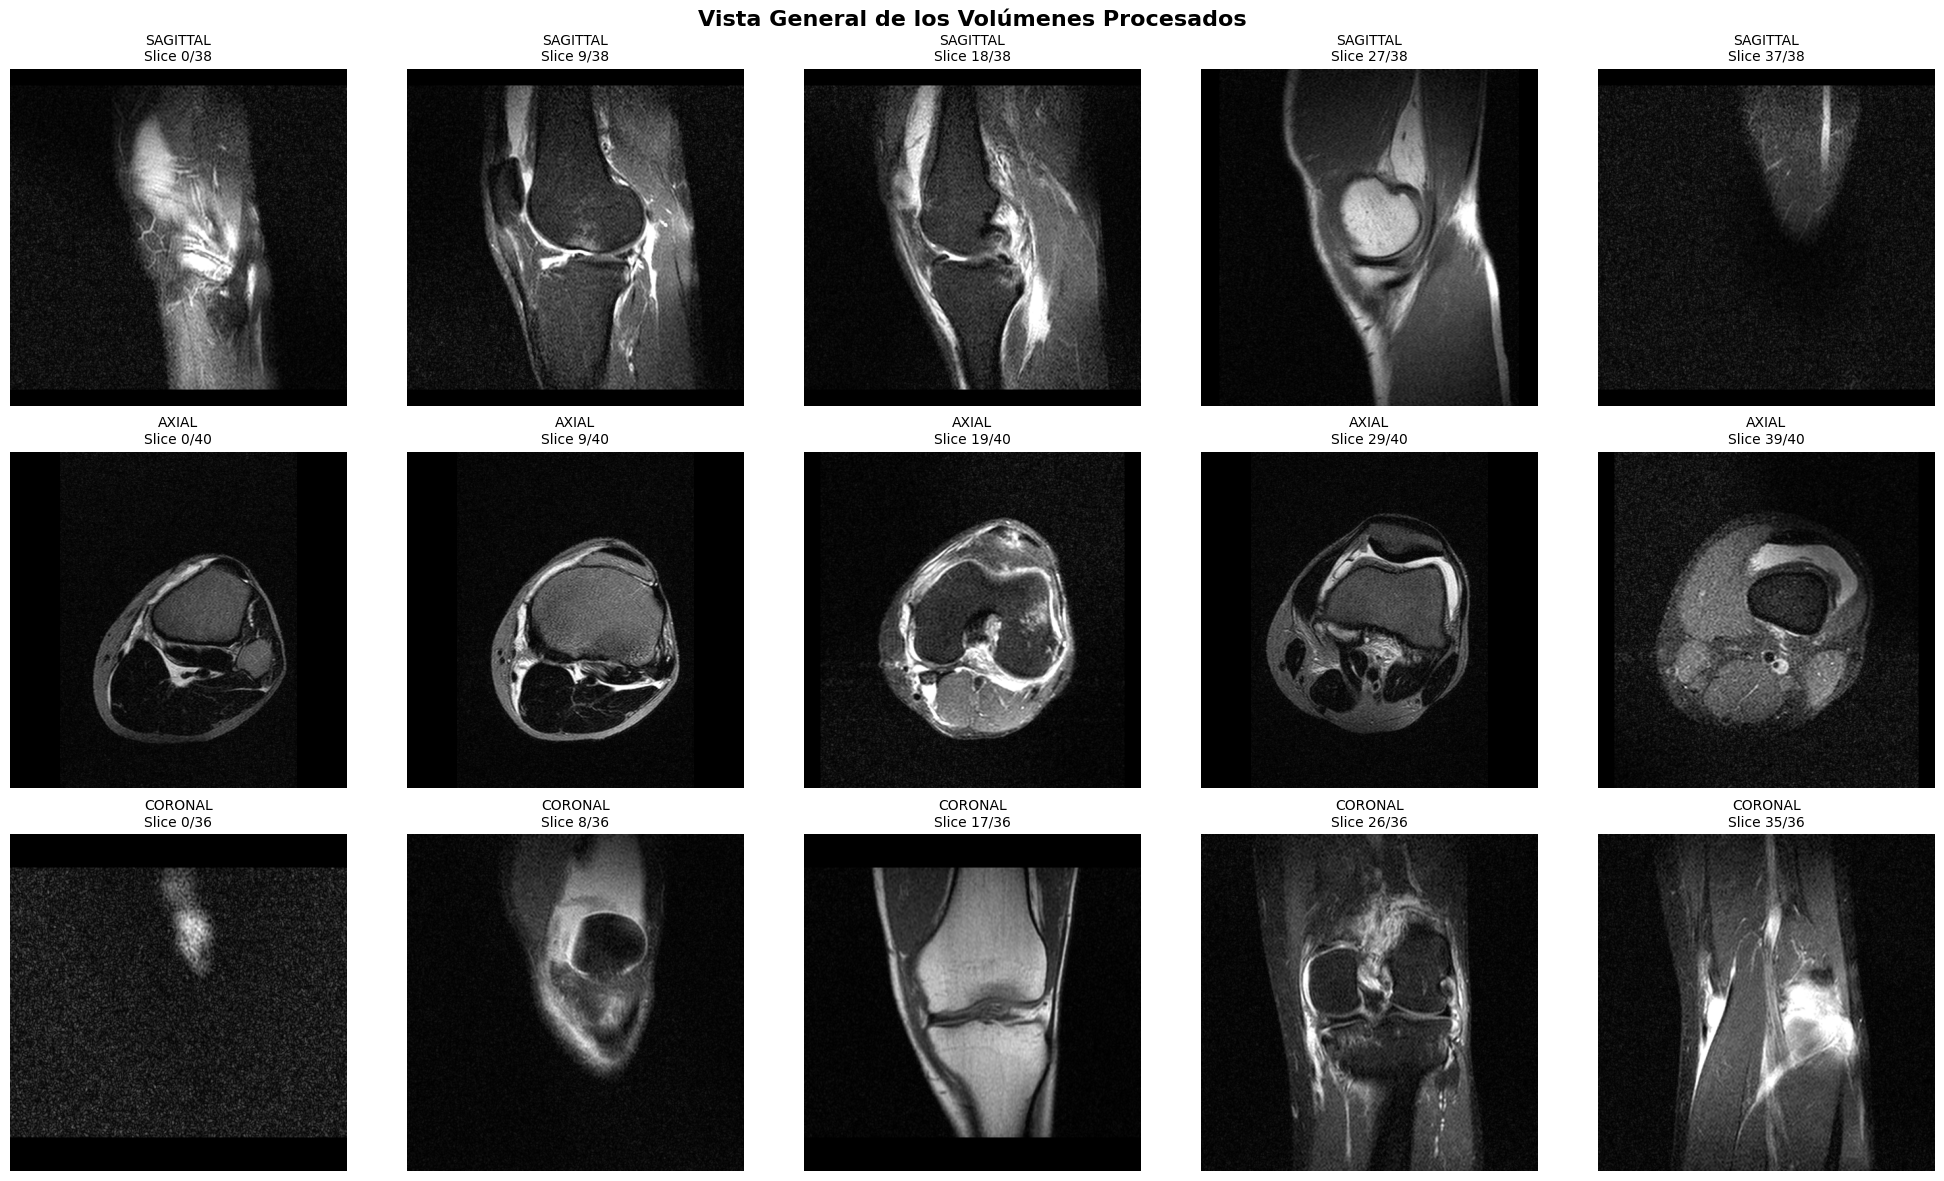

✅ Visualización completada

💡 Observa que:
   • Las imágenes deben mostrar estructuras anatómicas de la rodilla
   • La calidad debe ser suficiente para distinguir tejidos
   • El contraste debe ser adecuado


In [38]:
# ==========================================
# VISUALIZACIÓN DE SLICES
# ==========================================

if 'npy_paths' in globals() and npy_paths:
    # Crear figura con subplots para los 3 planos
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    
    for idx, (plane, path) in enumerate(npy_paths.items()):
        vol = np.load(path)
        total_slices = vol.shape[0]
        
        # Seleccionar 5 slices espaciados uniformemente
        slice_indices = np.linspace(0, total_slices - 1, 5, dtype=int)
        
        for col, slice_idx in enumerate(slice_indices):
            ax = axes[idx, col]
            ax.imshow(vol[slice_idx], cmap='gray')
            ax.set_title(f'{plane.upper()}\nSlice {slice_idx}/{total_slices}', fontsize=10)
            ax.axis('off')
    
    plt.suptitle('Vista General de los Volúmenes Procesados', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualización completada")
    print("\n💡 Observa que:")
    print("   • Las imágenes deben mostrar estructuras anatómicas de la rodilla")
    print("   • La calidad debe ser suficiente para distinguir tejidos")
    print("   • El contraste debe ser adecuado")
else:
    print("⚠️  No hay datos para visualizar.")

## 7d. Ejecutar Predicción ACL

Ahora ejecutamos los modelos sobre los datos procesados.

In [39]:
# ==========================================
# EJECUTAR PREDICCIÓN
# ==========================================

def probability_to_risk_score(prob: float, threshold: float = 0.35) -> float:
    """
    Convierte probabilidad con umbral custom a Risk Score 0-100 con umbral en 50.
    
    Args:
        prob: Probabilidad original (0-1)
        threshold: Umbral de clasificación original (0.35)
    
    Returns:
        Risk Score reescalado (0-100) donde 50 es el umbral
    """
    if prob < threshold:
        # Mapear 0-threshold a 0-50
        return (prob / threshold) * 50
    else:
        # Mapear threshold-1.0 a 50-100
        return 50 + ((prob - threshold) / (1 - threshold)) * 50


def get_risk_category(risk_score: float) -> tuple:
    """
    Categoriza el risk score en niveles de riesgo.
    
    Returns:
        (emoji, category, color)
    """
    if risk_score >= 75:
        return ("🔴", "RIESGO MUY ALTO", "red")
    elif risk_score >= 60:
        return ("🟠", "RIESGO ALTO", "orange")
    elif risk_score >= 50:
        return ("🟡", "RIESGO MODERADO", "yellow")
    elif risk_score >= 30:
        return ("🟢", "RIESGO BAJO", "lightgreen")
    else:
        return ("✅", "RIESGO MUY BAJO", "green")


if 'npy_paths' in globals() and npy_paths and 'models' in globals():
    # Ejecutar predicción
    predictions = predict_acl_tear(npy_paths, models, DEVICE, 
                                   cnn_selector_sagittal, cnn_selector_coronal)
    
    # Análisis de resultados
    print("\n" + "=" * 70)
    print("📊 ANÁLISIS DE RESULTADOS")
    print("=" * 70 + "\n")
    
    valid_predictions = {k: v for k, v in predictions.items() if v is not None}
    
    if valid_predictions:
        # Mostrar tabla de resultados con Risk Score
        print(f"{'Plano':12s} | Risk Score | Categoría de Riesgo")
        print("-" * 60)
        for plane, prob in valid_predictions.items():
            risk_score = probability_to_risk_score(prob)
            emoji, category, _ = get_risk_category(risk_score)
            print(f"{plane.upper():12s} | {risk_score:8.1f}% | {emoji} {category}")
        
        # Predicción ensemble (promedio ponderado por AUC)
        # AUCs de validación: sagittal=0.9534, coronal=0.9346, axial=0.9755
        auc_weights = {
            'sagittal': 0.9534,
            'coronal': 0.9346,
            'axial': 0.9755
        }
        
        weighted_sum = 0
        weight_total = 0
        for plane, prob in valid_predictions.items():
            if plane in auc_weights:
                weighted_sum += prob * auc_weights[plane]
                weight_total += auc_weights[plane]
        
        ensemble_prob = weighted_sum / weight_total if weight_total > 0 else 0
        ensemble_risk_score = probability_to_risk_score(ensemble_prob)
        
        print("\n" + "=" * 70)
        print("🎯 RESULTADO ENSEMBLE (COMBINADO)")
        print("=" * 70 + "\n")
        
        print(f"Risk Score del ensemble: {ensemble_risk_score:.1f}%")
        
        # Diagnóstico final
        print("\n" + "=" * 70)
        print("🏥 DIAGNÓSTICO FINAL")
        print("=" * 70)
        
        emoji, category, _ = get_risk_category(ensemble_risk_score)
        
        if ensemble_risk_score >= 75:
            diagnosis = "LESIÓN ACL MUY PROBABLE"
            confidence = "MUY ALTA"
            recommendation = "⚠️  Requiere evaluación clínica URGENTE"
            clinical_note = "Hallazgos altamente sugestivos de ruptura completa del LCA"
        elif ensemble_risk_score >= 60:
            diagnosis = "LESIÓN ACL PROBABLE"
            confidence = "ALTA"
            recommendation = "⚠️  Requiere evaluación clínica especializada"
            clinical_note = "Hallazgos compatibles con lesión del LCA"
        elif ensemble_risk_score >= 50:
            diagnosis = "SOSPECHA DE LESIÓN ACL"
            confidence = "MODERADA"
            recommendation = "📋 Recomendado análisis adicional y correlación clínica"
            clinical_note = "Signos que sugieren posible compromiso del LCA"
        elif ensemble_risk_score >= 30:
            diagnosis = "LCA APARENTEMENTE NORMAL"
            confidence = "MODERADA-ALTA"
            recommendation = "✓ Seguimiento si hay síntomas clínicos persistentes"
            clinical_note = "No se observan signos claros de lesión"
        else:
            diagnosis = "LCA NORMAL"
            confidence = "MUY ALTA"
            recommendation = "✓ No se requiere seguimiento adicional"
            clinical_note = "Integridad del LCA preservada"
        
        print(f"\n{emoji} {diagnosis}")
        print(f"   Risk Score: {ensemble_risk_score:.1f}%")
        print(f"   Categoría: {category}")
        print(f"   Confianza: {confidence}")
        print(f"\n💡 Hallazgos:")
        print(f"   {clinical_note}")
        print(f"\n📋 Recomendación:")
        print(f"   {recommendation}")
        
        # Información técnica adicional (colapsable)
        print("\n" + "-" * 70)
        print("📊 Información Técnica Detallada:")
        print("-" * 70)
        print(f"Probabilidad técnica del modelo: {ensemble_prob:.1%}")
        print(f"Umbral de clasificación: 35%")
        print(f"Método: Ensemble ponderado por AUC de validación")
        print("\n💡 Nota: El Risk Score está calibrado para interpretación clínica.")
        print("   Un score ≥50% indica alta probabilidad de lesión del LCA.")
        
        print("\n" + "=" * 70)
        print("\n⚠️  IMPORTANTE: Sistema de apoyo al diagnóstico")
        print("   • Este análisis debe ser validado por profesionales médicos")
        print("   • No sustituye el criterio clínico especializado")
        print("   • Considerar historia clínica, exploración física y otros estudios")
        print("=" * 70)
        
    else:
        print("❌ No se pudieron obtener predicciones válidas")
        
else:
    print("⚠️  Faltan datos o modelos para ejecutar la predicción.")
    print("   Asegúrate de haber ejecutado las celdas anteriores.")


PREDICCIONES DE LESIÓN ACL

  📂 SAGITTAL  : 38 slices
    🔍 Slices CNN-seleccionados (Sagital): [10, 12, 14, 15, 17]
    Probabilidad: 38.8%
    Diagnóstico:  🔴 LESIÓN ACL (Confianza: Moderada)
    📊 Slice más relevante: #0 (atención: 26.92%)

  📂 AXIAL     : 40 slices
    📍 Slices centrales: [15:25]
    Probabilidad: 96.9%
    Diagnóstico:  🔴 LESIÓN ACL (Confianza: Alta)
    📊 Slice más relevante: #4 (atención: 20.76%)

  📂 CORONAL   : 36 slices
    🔍 Slices CNN-seleccionados (Coronal): [13, 18, 19, 20, 21, 22, 23, 24, 25, 27]
    Probabilidad: 38.4%
    Diagnóstico:  🔴 LESIÓN ACL (Confianza: Moderada)


📊 ANÁLISIS DE RESULTADOS

Plano        | Risk Score | Categoría de Riesgo
------------------------------------------------------------
SAGITTAL     |     52.9% | 🟡 RIESGO MODERADO
AXIAL        |     97.6% | 🔴 RIESGO MUY ALTO
CORONAL      |     52.6% | 🟡 RIESGO MODERADO

🎯 RESULTADO ENSEMBLE (COMBINADO)

Risk Score del ensemble: 68.0%

🏥 DIAGNÓSTICO FINAL

🟠 LESIÓN ACL PROBABLE
   Ris

## 8. Funciones de Visualización

In [40]:
# ==========================================
# VISUALIZACIÓN
# ==========================================

def visualize_slices(npy_path: Path, num_slices_to_show: int = 6):
    """
    Visualiza slices de un volumen NPY.
    
    Args:
        npy_path: Ruta al archivo NPY
        num_slices_to_show: Número de slices a visualizar
    """
    volume = np.load(npy_path)
    total_slices = volume.shape[0]
    
    # Seleccionar slices espaciados uniformemente
    indices = np.linspace(0, total_slices - 1, num_slices_to_show, dtype=int)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i < len(axes):
            axes[i].imshow(volume[idx], cmap='gray')
            axes[i].set_title(f'Slice {idx}/{total_slices}')
            axes[i].axis('off')
    
    plt.suptitle(f'Visualización: {npy_path.stem}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# 📝 EJEMPLO DE USO (ejecutar después de procesar el ZIP):
"""
if ZIP_PATH is not None and npy_paths:
    for plane, path in npy_paths.items():
        print(f"\n📊 Visualizando plano: {plane.upper()}")
        visualize_slices(path)
"""

print("✅ Funciones de visualización definidas")

✅ Funciones de visualización definidas


## 9. Notas Finales

### 📝 Información del Sistema

**Threshold de clasificación**: 0.35  
**CNN Selector**: MobileNetV2 (F1=0.8563) para slices sagitales  
**Arquitectura**: Vision Transformer (ViT) con attention pooling  
**Ensemble**: Promedio ponderado por AUC de validación

### ⚠️ Disclaimer

Este sistema es una herramienta de apoyo al diagnóstico. Las predicciones **deben ser validadas por profesionales médicos cualificados**.

## 10. Visualización de Mapas de Atención

Visualizamos las slices más relevantes según los pesos de atención de cada modelo.

🎨 Generando visualizaciones de mapas de atención...

    🔍 Slices CNN-seleccionados (Sagital): [10, 12, 14, 15, 17]
    📍 Slices centrales: [15:25]
    🔍 Slices CNN-seleccionados (Coronal): [13, 18, 19, 20, 21, 22, 23, 24, 25, 27]


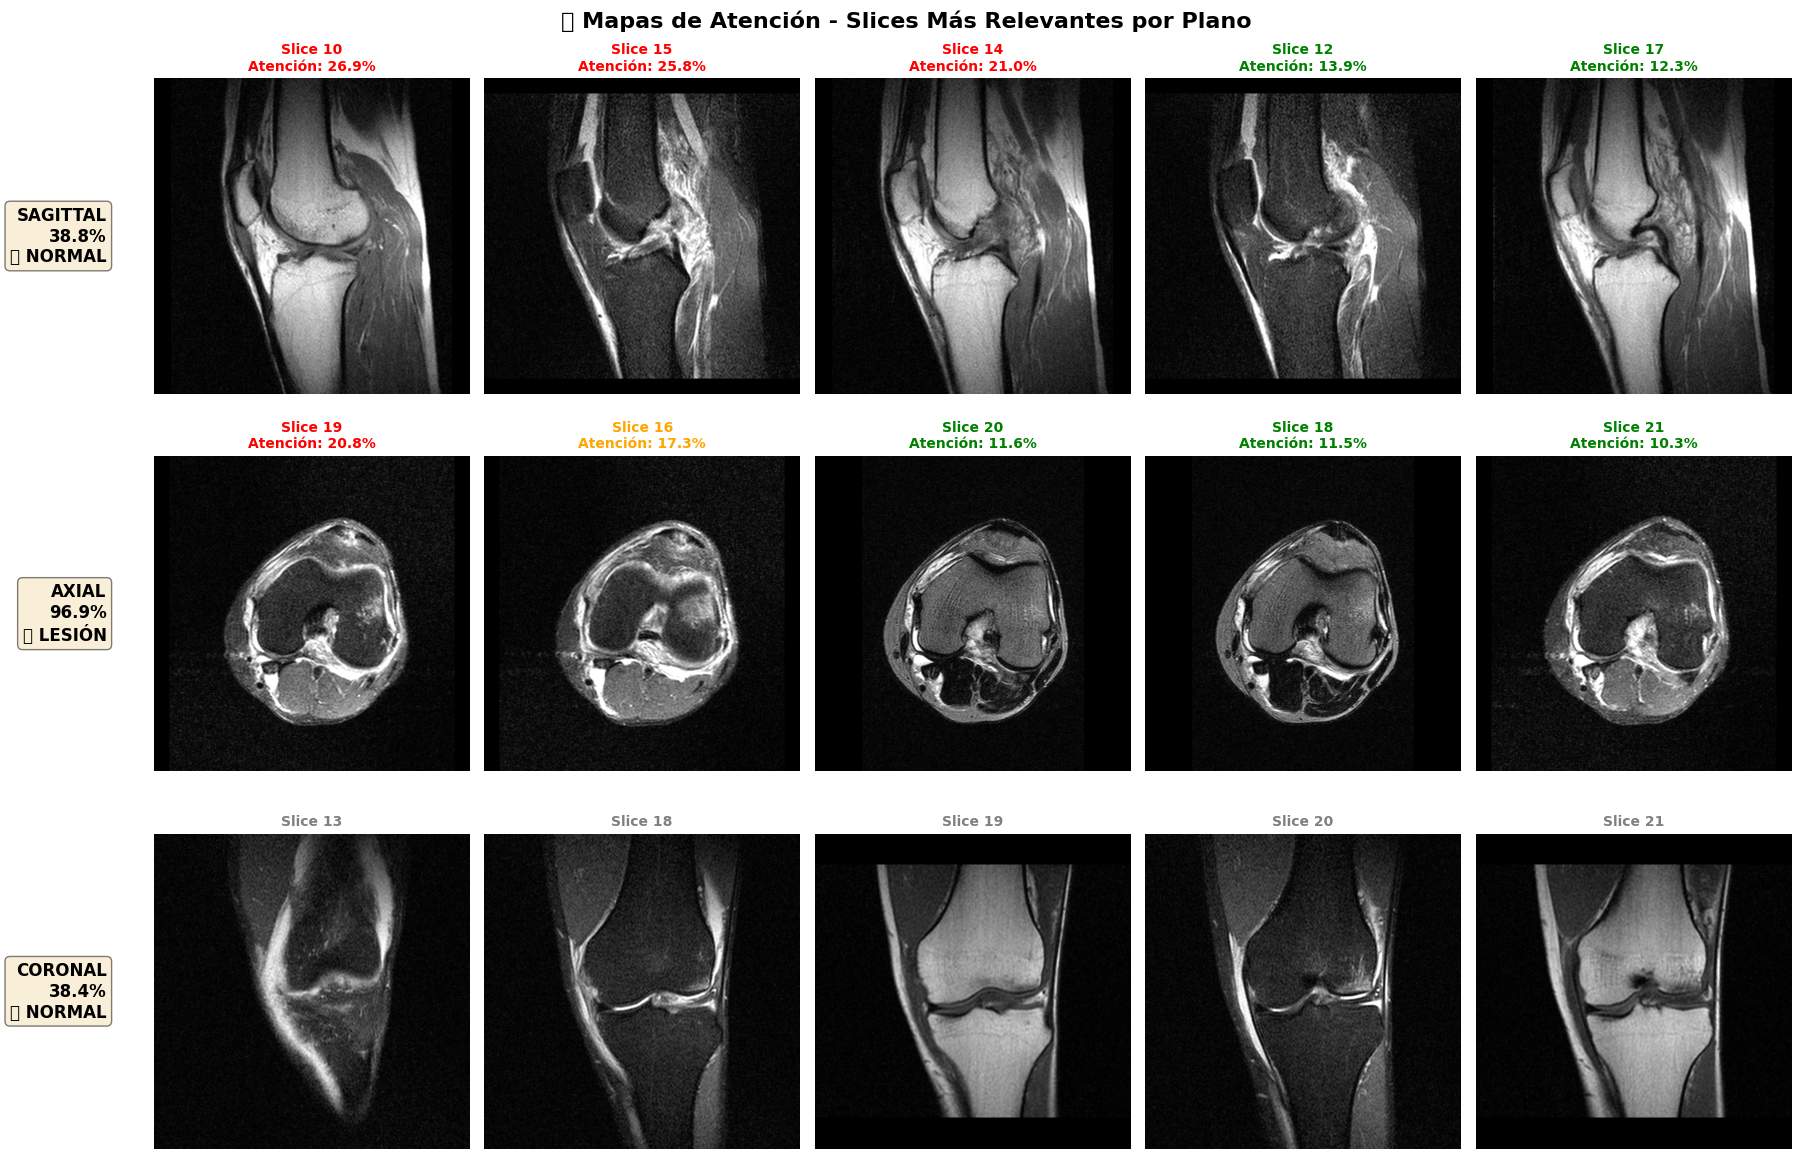

    🔍 Slices CNN-seleccionados (Sagital): [10, 12, 14, 15, 17]
    📍 Slices centrales: [15:25]
    🔍 Slices CNN-seleccionados (Coronal): [13, 18, 19, 20, 21, 22, 23, 24, 25, 27]


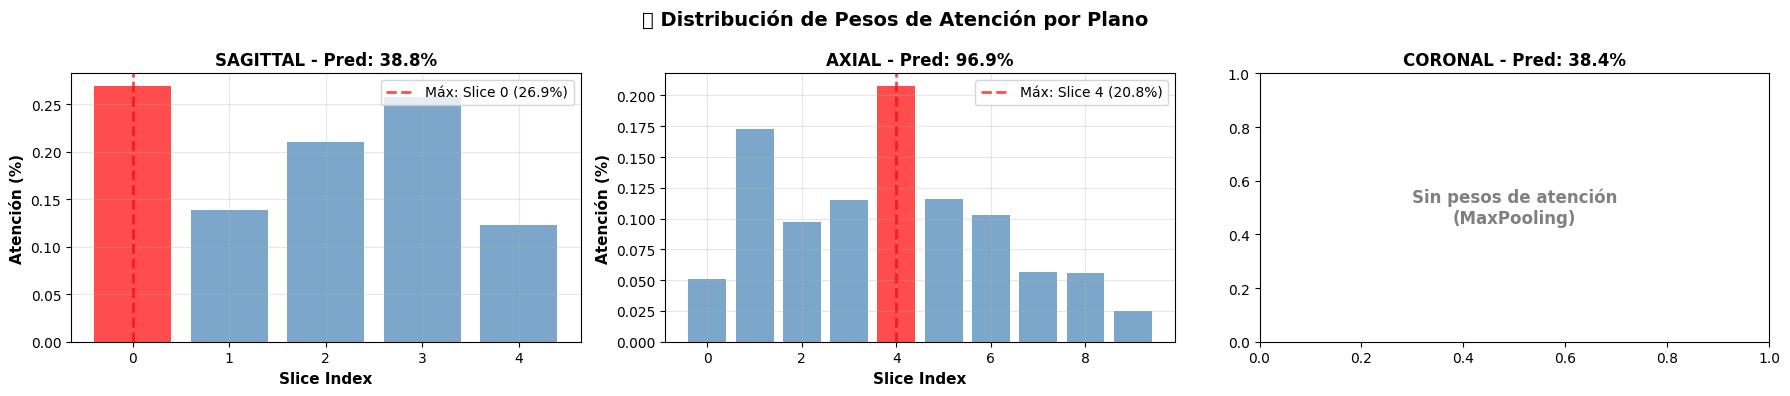

In [41]:
# ==========================================
# VISUALIZACIÓN DE MAPAS DE ATENCIÓN
# ==========================================

def visualize_attention_maps(npy_paths: Dict[str, Path], models: Dict[str, ACLClassifier], 
                              predictions: Dict[str, float], cnn_selector_sagittal=None,
                              cnn_selector_coronal=None):
    """
    Visualiza las slices más relevantes con sus pesos de atención.
    """
    fig, axes = plt.subplots(3, 5, figsize=(18, 12))
    fig.suptitle('🎯 Mapas de Atención - Slices Más Relevantes por Plano', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for row, plane in enumerate(['sagittal', 'axial', 'coronal']):
        if plane not in npy_paths or plane not in models:
            continue
            
        # Cargar volumen
        volume = np.load(npy_paths[plane])
        num_slices = PLANE_CONFIG[plane]['num_slices']
        
        # Obtener slices seleccionados
        if plane == 'sagittal' and cnn_selector_sagittal is not None:
            volume_normalized = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
            selected_indices = cnn_selector_sagittal.select_top_k_slices(volume_normalized, k=num_slices)
            selected_slices = volume[selected_indices]
        elif plane == 'coronal' and cnn_selector_coronal is not None:
            volume_normalized = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
            selected_indices = cnn_selector_coronal.select_top_k_slices(volume_normalized, k=num_slices)
            selected_slices = volume[selected_indices]
        else:
            start_idx = max(0, (volume.shape[0] - num_slices) // 2)
            end_idx = start_idx + num_slices
            selected_slices = volume[start_idx:end_idx]
            selected_indices = np.arange(start_idx, end_idx)
        
        # Obtener pesos de atención
        volume_tensor = preprocess_volume_for_model(volume, num_slices, plane, IMAGE_SIZE, 
                                                    cnn_selector_sagittal, cnn_selector_coronal)
        volume_tensor = volume_tensor.to(DEVICE)
        
        with torch.no_grad():
            _, attention_weights = models[plane](volume_tensor)
        
        if attention_weights is not None:
            attn_np = attention_weights.cpu().numpy()[0]
            # Top 5 slices por atención
            top_k = min(5, len(attn_np))
            top_indices = np.argsort(attn_np)[-top_k:][::-1]
        else:
            # Si no hay atención (coronal), mostrar slices centrales
            top_indices = np.arange(min(5, len(selected_slices)))
        
        # Visualizar top 5 slices
        for col, idx in enumerate(top_indices):
            ax = axes[row, col]
            slice_2d = selected_slices[idx]
            
            # Normalizar para visualización
            slice_vis = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)
            
            ax.imshow(slice_vis, cmap='gray')
            ax.axis('off')
            
            # Información del slice
            if attention_weights is not None:
                attn_val = attn_np[idx]
                title = f"Slice {selected_indices[idx]}\nAtención: {attn_val:.1%}"
                color = 'red' if attn_val > 0.2 else 'orange' if attn_val > 0.15 else 'green'
            else:
                title = f"Slice {selected_indices[idx]}"
                color = 'gray'
            
            ax.set_title(title, fontsize=10, fontweight='bold', color=color)
        
        # Añadir información del plano en el borde izquierdo
        pred_prob = predictions.get(plane, 0)
        status = "🔴 LESIÓN" if pred_prob > 0.5 else "🟢 NORMAL"
        
        axes[row, 0].text(-0.15, 0.5, f'{plane.upper()}\n{pred_prob:.1%}\n{status}', 
                          transform=axes[row, 0].transAxes,
                          fontsize=12, fontweight='bold', 
                          va='center', ha='right',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Gráfico de barras con pesos de atención
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle('📊 Distribución de Pesos de Atención por Plano', 
                 fontsize=14, fontweight='bold')
    
    for idx, plane in enumerate(['sagittal', 'axial', 'coronal']):
        if plane not in models:
            continue
            
        ax = axes[idx]
        volume = np.load(npy_paths[plane])
        num_slices = PLANE_CONFIG[plane]['num_slices']
        
        # Obtener attention weights
        volume_tensor = preprocess_volume_for_model(volume, num_slices, plane, IMAGE_SIZE, 
                                                    cnn_selector_sagittal, cnn_selector_coronal)
        volume_tensor = volume_tensor.to(DEVICE)
        
        with torch.no_grad():
            _, attention_weights = models[plane](volume_tensor)
        
        if attention_weights is not None:
            attn_np = attention_weights.cpu().numpy()[0]
            
            # Crear gráfico de barras
            colors = ['red' if a == max(attn_np) else 'steelblue' for a in attn_np]
            bars = ax.bar(range(len(attn_np)), attn_np, color=colors, alpha=0.7)
            
            ax.set_xlabel('Slice Index', fontsize=11, fontweight='bold')
            ax.set_ylabel('Atención (%)', fontsize=11, fontweight='bold')
            ax.set_title(f'{plane.upper()} - Pred: {predictions[plane]:.1%}', 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Resaltar slice más relevante
            max_idx = np.argmax(attn_np)
            ax.axvline(max_idx, color='red', linestyle='--', linewidth=2, alpha=0.7,
                      label=f'Máx: Slice {max_idx} ({attn_np[max_idx]:.1%})')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'Sin pesos de atención\n(MaxPooling)', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=12, fontweight='bold', color='gray')
            ax.set_title(f'{plane.upper()} - Pred: {predictions[plane]:.1%}', 
                        fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


# Ejecutar visualización
if npy_paths and models and predictions:
    print("🎨 Generando visualizaciones de mapas de atención...\n")
    visualize_attention_maps(npy_paths, models, predictions, cnn_selector_sagittal, cnn_selector_coronal)
else:
    print("⚠️  Asegúrate de ejecutar primero las celdas de procesamiento y predicción")

## 11. Visualización de Slices Seleccionados por CNN Selector

Visualizamos los slices específicos que selecciona cada CNN Selector (sagital y coronal).

🔍 SLICES SELECCIONADOS POR CNN SELECTORS

📌 SAGITTAL
   Total de slices en volumen: 38
   Slices seleccionados: [10, 12, 14, 15, 17]
   Cantidad: 5



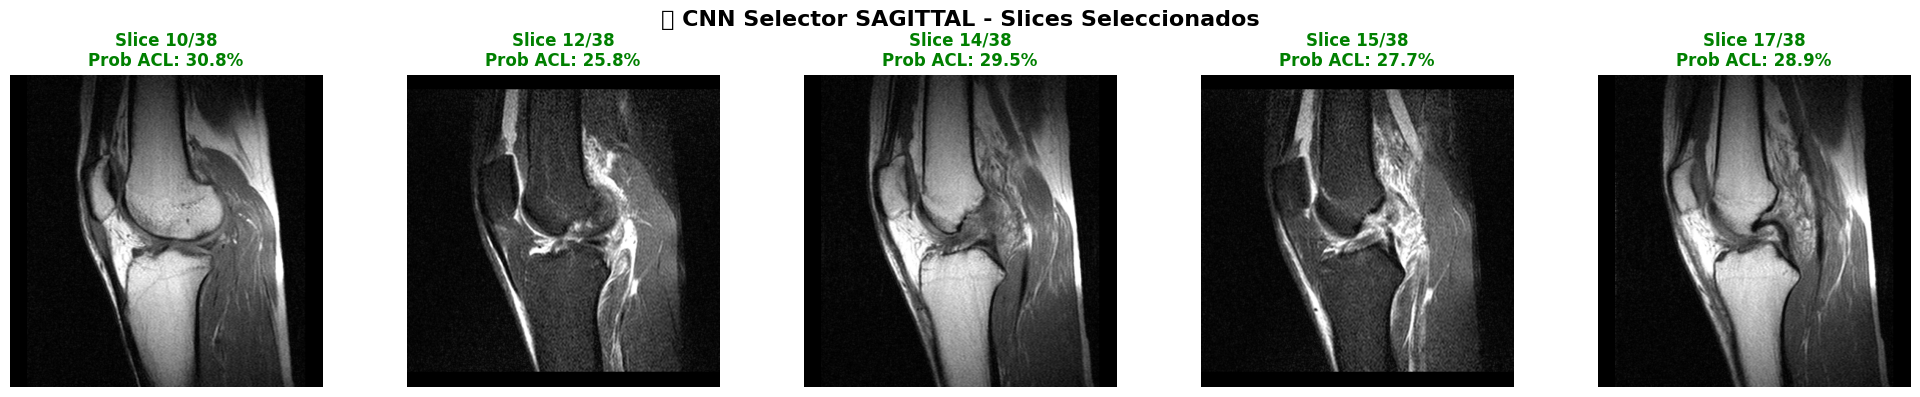

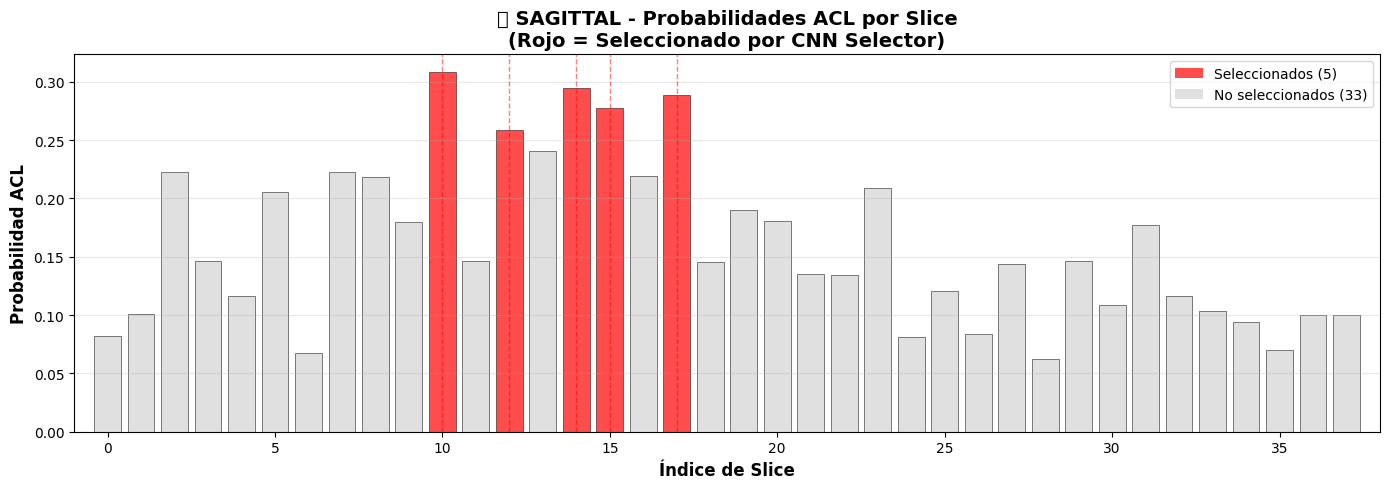

----------------------------------------------------------------------

📌 CORONAL
   Total de slices en volumen: 36
   Slices seleccionados: [13, 18, 19, 20, 21, 22, 23, 24, 25, 27]
   Cantidad: 10



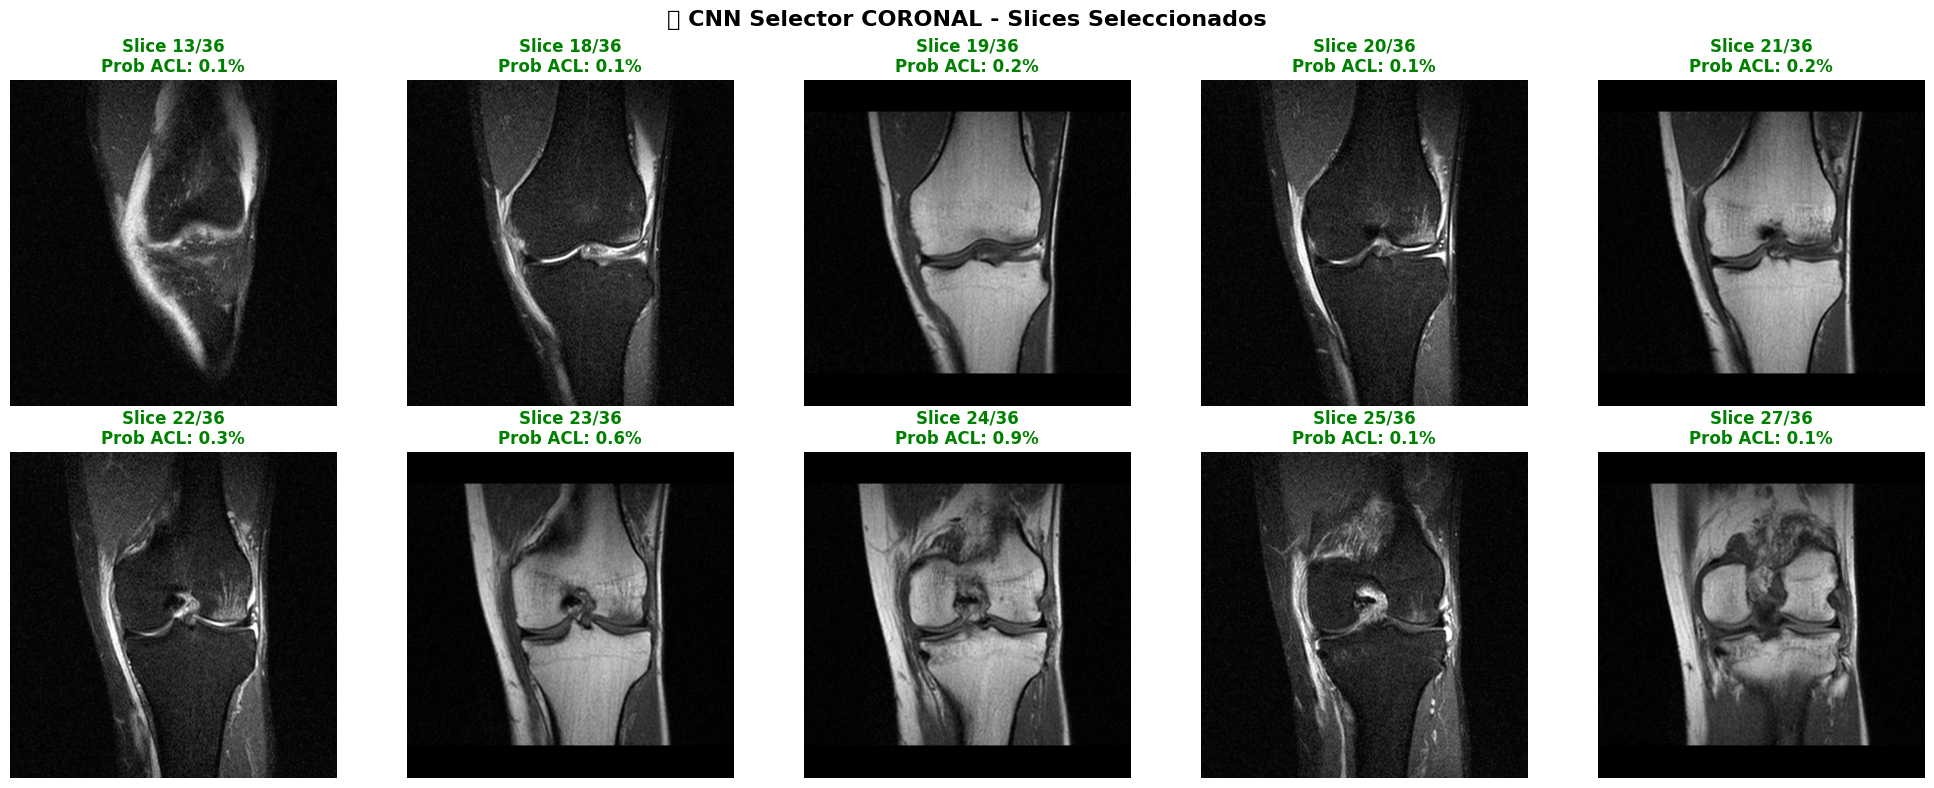

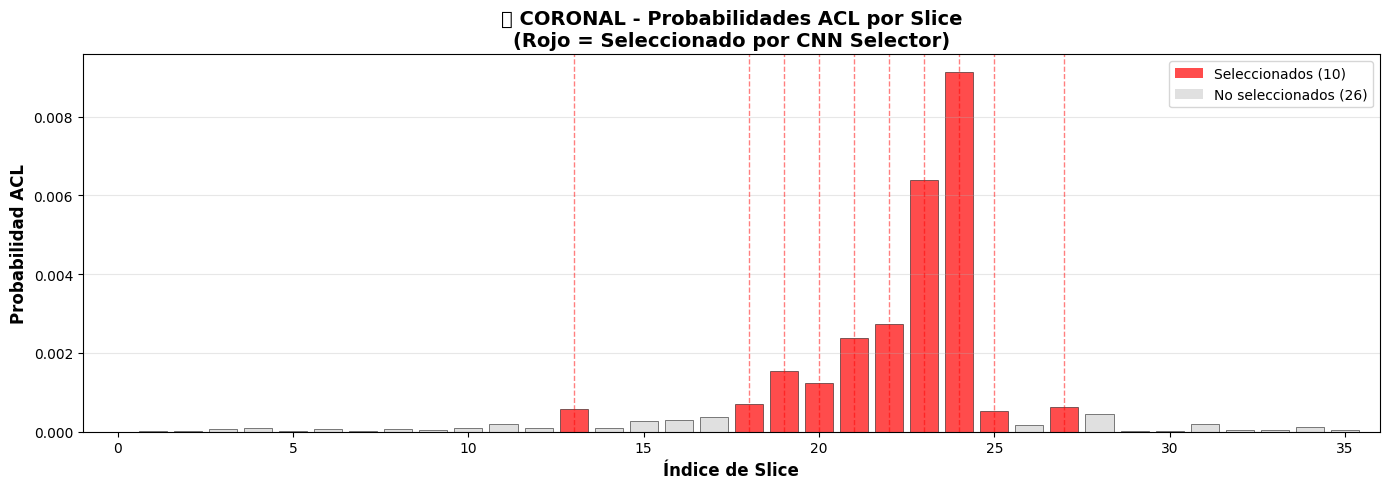

----------------------------------------------------------------------



In [42]:
# ==========================================
# VISUALIZACIÓN DE SLICES SELECCIONADOS
# ==========================================

if 'npy_paths' in globals() and npy_paths:
    print("=" * 70)
    print("🔍 SLICES SELECCIONADOS POR CNN SELECTORS")
    print("=" * 70 + "\n")
    
    # Preparar figura para ambos planos
    planes_to_show = []
    if 'sagittal' in npy_paths and cnn_selector_sagittal is not None:
        planes_to_show.append(('sagittal', cnn_selector_sagittal, 5))
    if 'coronal' in npy_paths and cnn_selector_coronal is not None:
        planes_to_show.append(('coronal', cnn_selector_coronal, 10))
    
    if planes_to_show:
        for plane, cnn_selector, num_slices in planes_to_show:
            # Cargar volumen
            volume = np.load(npy_paths[plane])
            total_slices = volume.shape[0]
            
            # Normalizar volumen
            volume_normalized = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
            
            # Obtener slices seleccionados
            selected_indices = cnn_selector.select_top_k_slices(volume_normalized, k=num_slices)
            
            print(f"📌 {plane.upper()}")
            print(f"   Total de slices en volumen: {total_slices}")
            print(f"   Slices seleccionados: {selected_indices}")
            print(f"   Cantidad: {len(selected_indices)}\n")
            
            # Visualizar slices seleccionados
            cols = 5
            rows = (len(selected_indices) + cols - 1) // cols
            
            fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
            fig.suptitle(f'🔍 CNN Selector {plane.upper()} - Slices Seleccionados', 
                        fontsize=16, fontweight='bold')
            
            # Aplanar axes si es array multidimensional
            if rows > 1:
                axes = axes.flatten()
            elif rows == 1 and cols > 1:
                axes = axes
            else:
                axes = [axes]
            
            # Mostrar cada slice seleccionado
            for i, slice_idx in enumerate(selected_indices):
                if i < len(axes):
                    ax = axes[i]
                    
                    # Obtener slice original (sin normalizar para mejor visualización)
                    slice_2d = volume[slice_idx]
                    
                    # Calcular probabilidad ACL para este slice
                    prob = cnn_selector.get_acl_probability(volume_normalized[slice_idx])
                    
                    # Visualizar
                    im = ax.imshow(slice_2d, cmap='gray')
                    ax.set_title(f'Slice {slice_idx}/{total_slices}\nProb ACL: {prob:.1%}', 
                               fontsize=12, fontweight='bold',
                               color='red' if prob > 0.7 else 'orange' if prob > 0.5 else 'green')
                    ax.axis('off')
            
            # Ocultar axes sobrantes
            for i in range(len(selected_indices), len(axes)):
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Gráfico de barras con probabilidades
            fig, ax = plt.subplots(1, 1, figsize=(14, 5))
            
            # Calcular probabilidades para todos los slices
            all_probs = []
            for i in range(total_slices):
                prob = cnn_selector.get_acl_probability(volume_normalized[i])
                all_probs.append(prob)
            
            # Crear gráfico
            x = np.arange(total_slices)
            colors = ['red' if i in selected_indices else 'lightgray' for i in x]
            bars = ax.bar(x, all_probs, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
            
            # Resaltar slices seleccionados
            for idx in selected_indices:
                ax.axvline(idx, color='red', linestyle='--', linewidth=1, alpha=0.5)
            
            ax.set_xlabel('Índice de Slice', fontsize=12, fontweight='bold')
            ax.set_ylabel('Probabilidad ACL', fontsize=12, fontweight='bold')
            ax.set_title(f'📊 {plane.upper()} - Probabilidades ACL por Slice\n(Rojo = Seleccionado por CNN Selector)', 
                        fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_xlim(-1, total_slices)
            
            # Añadir leyenda
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='red', alpha=0.7, label=f'Seleccionados ({len(selected_indices)})'),
                Patch(facecolor='lightgray', alpha=0.7, label=f'No seleccionados ({total_slices - len(selected_indices)})')
            ]
            ax.legend(handles=legend_elements, loc='upper right')
            
            plt.tight_layout()
            plt.show()
            
            print("-" * 70 + "\n")
    else:
        print("⚠️  No hay CNN Selectors disponibles.")
        print("   Asegúrate de que los modelos se hayan cargado correctamente.\n")
else:
    print("⚠️  No hay datos procesados.")
    print("   Ejecuta primero las celdas de procesamiento.")